在前面的课程里，我们实现了一个 MLP 结构的 character level 的语言模型。我们接收3个先前的字母输入，然后使用一个非常简单的，只有一个隐藏层的MLP来预测序列里的第四个字母输出。在这节课里，我们会把这个结构变得更加复杂。我们会引入更多的输入字母，不单单是前面的3个。此外我们不会把它们输入到一个简单的隐藏层，因为这样激活函数会过快地压缩过多信息而导致信息损失，我们会制作一个更深的模型来预测序列里的下一个字母。
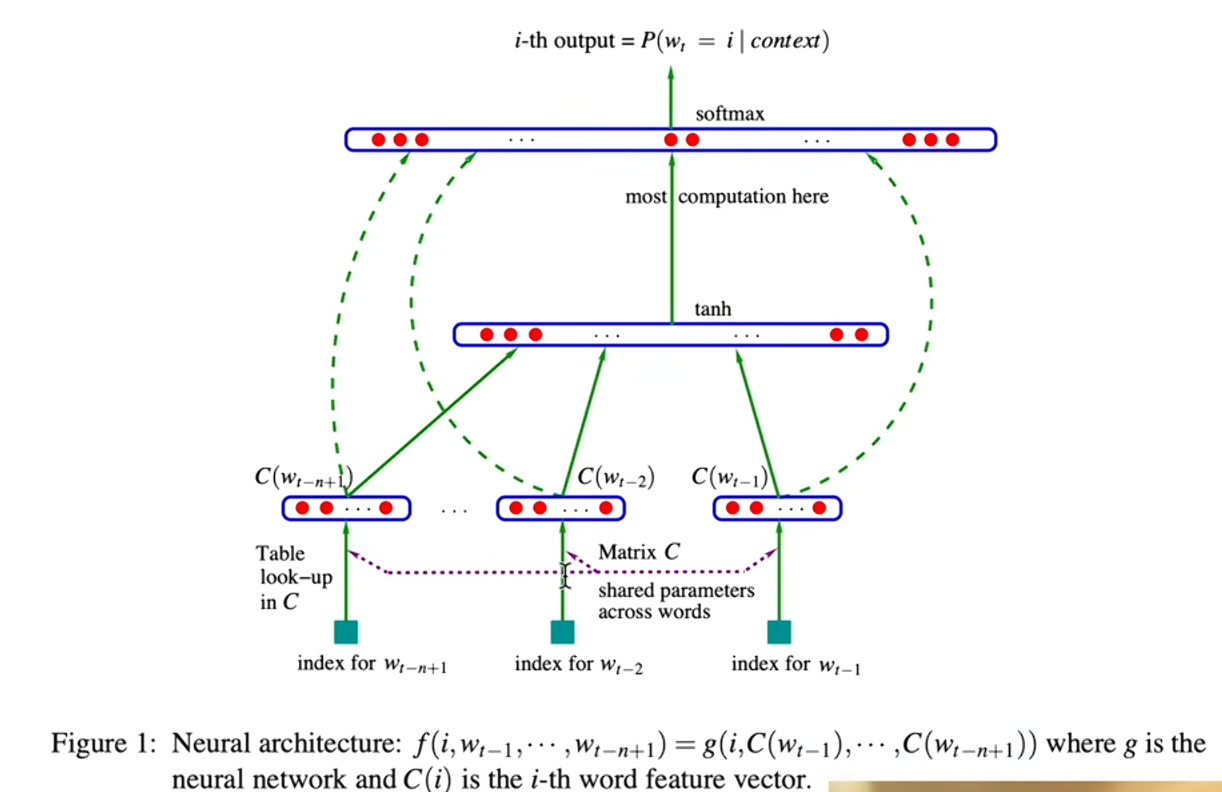

当我们将模型结构进一步复杂时，会发现它实际上与 WaveNet 非常相似。WaveNet 是 DeepMind 于 2016 年发表的一篇论文中提出的模型，它是一种用于生成原始音频波形的自回归模型，而不是处理字符或单词级别的语言模型。但是基本上模型的设置什么的都是相似的。它是一个 auto regressive model(自回归模型) ，并且试图去预测序列里的下一个character。它的架构使用一种hierarchical (分层)的方法，采用一种street-like的结构来预测

In [33]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [34]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [35]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [36]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [37]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])        #80%
Xdev, Ydev = build_dataset(words[n1:n2])    #10%
Xte, Yte = build_dataset(words[n2:])        #10%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [38]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[i.item()] for i in x), '-->', itos[y.item()])

... --> e
..e --> b
.eb --> r
ebr --> i
bri --> m
rim --> a
ima --> .
... --> h
..h --> i
.hi --> l
hil --> t
ilt --> o
lto --> n
ton --> .
... --> j
..j --> h
.jh --> e
jhe --> n
hen --> e
ene --> .


In [39]:
# Near copy paste of the layers we have developed in Part 3

#--------------------------------------------------------------------------------------------------
class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.randn(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
#--------------------------------------------------------------------------------------------------   
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters(trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers(trained with a running 'momentum updata')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean=x.mean(0, keepdim=True)   # batch mean, 计算当前批次的均值
            xvar=x.var(0, keepdim=True)     # batch variance, 计算当前批次的方差
        else:
            xmean=self.running_mean
            xvar=self.running_var

        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)    # normalize the batch, 对当前批次的数据进行标准化
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = self.momentum * xmean + (1-self.momentum) * self.running_mean
                self.running_var = self.momentum * xvar + (1-self.momentum) * self.running_var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
#--------------------------------------------------------------------------------------------------       
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
#--------------------------------------------------------------------------------------------------
class Embedding:    # 这里是一个简单的Embedding层实现，用于将离散的索引映射到连续的向量空间中。这样就不用查表emb=C[Xb]了

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, ix):
        self.out = self.weight[ix]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
#--------------------------------------------------------------------------------------------------
class Flatten:      # 同样，这里是一个简单的Flatten层实现，用于将输入张量展平为二维张量，以便后续的全连接层处理。就不需要手动去reshape了(虽然我们也用的是view)

    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    
#--------------------------------------------------------------------------------------------------
class Sequential:   # Sequential类用于将多个层组合在一起，形成一个顺序的神经网络模型。它接受一个层的列表，并在调用时依次将输入传递给每一层。

    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # 返回所有层的参数列表
        return [p for layer in self.layers for p in layer.parameters()]

In [40]:
torch.manual_seed(42)

In [41]:
n_embd = 10     # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200  # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

model = Sequential([ 
    Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameters init, 参数初始化
with torch.no_grad():
    model.layers[-1].weight *= 0.1    # output layer is "weak" at the beginning, 输出层的权重初始化较小，让最后一层变得less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True

12097


In [48]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.4353
  10000/200000: 2.5284
  20000/200000: 2.2439
  30000/200000: 2.2641
  40000/200000: 2.3147
  50000/200000: 2.1299
  60000/200000: 1.9032
  70000/200000: 2.2420
  80000/200000: 2.0866
  90000/200000: 2.3235
 100000/200000: 1.8046
 110000/200000: 2.1842
 120000/200000: 1.7899
 130000/200000: 1.9389
 140000/200000: 2.0854
 150000/200000: 1.5930
 160000/200000: 2.3079
 170000/200000: 1.7964
 180000/200000: 2.1193
 190000/200000: 1.8773


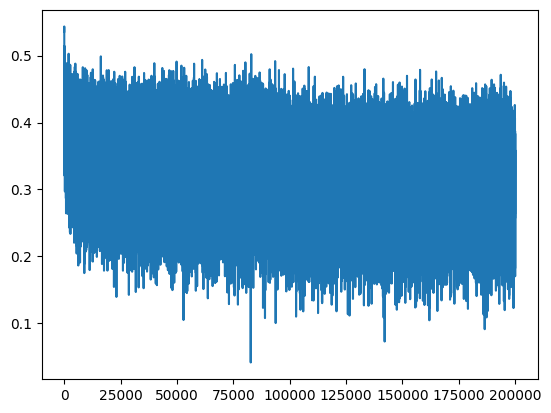

In [49]:
plt.plot(lossi)

从损失曲线来看，训练效果并不理想。原因在于 batch size 设置过小（仅为 32），这使得每个 mini-batch 的采样偏差较大，梯度估计不够稳定，从而导致损失曲线出现剧烈波动，而不是平滑下降

首先，我们让这个图的观感更好一点

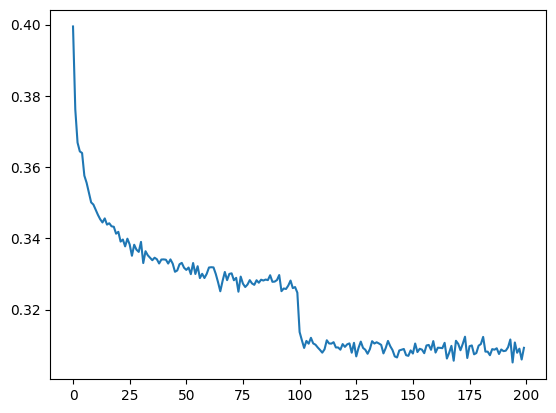

In [50]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
# 这里把lossi每1000个点取平均，画出平滑的曲线

In [51]:
# put layers into eval mode (needed for batchnorm especially)   进行评估模式，特别是对于batchnorm层
for layer in model.layers:
        layer.training = False

In [52]:
# evaluate the loss
@torch.no_grad()

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.043135643005371
val 2.104050397872925


In [53]:
# sample from the model

for _ in range(20):

    out = []
    context = [0] * block_size # initial context, 初始上下文

    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sampled the special end '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

nayla.
delo.
kamery.
danna.
evella.
akhie.
akvin.
tubrrat.
aszin.
caless.
stina.
ell.
jezhaelo.
lattina.
fin.
dakon.
kenzlinorentrelianor.
cyn.
thanushaanan.
emarimane.


好了，到目前为止，我们基本完成了前几节课的代码架构。我们的做法是：输入几个字母，经过一个单隐藏层，然后预测下一个字母。现在的问题是，我们找不到一个更朴素的方法来让这个结构变得更复杂。虽然我们可以增加层数、让网络更庞大，但本质上，我们仍然是在最开始就把所有输入字母一股脑地塞进一个层里。即便我们增加神经元、扩大网络规模，本质上还是在一开始就把所有信息迅速“压扁”了——这显然是很蠢的做法。

所以接下来，我们希望让神经网络做出改变，让它更像 WaveNet 那样。在 WaveNet 里，当我们预测序列中的下一个字母时，预测结果是前面输入字符的函数，但这些字符并不是一股脑地被压进一个单层里，然后像三明治一样糊弄过去——它们是被逐步压扁的。具体来说，我们会先取两个字符，把它们融合成一个类似“二元组合”（bigram）的表示，然后对序列中所有相邻的字符都这样依次处理下去。接着，我们把这些二元组合再融合成包含四个字母的块，然后以此类推，不断地往上融合，就像一棵二叉树的结构一样。通过这种方式，我们就把之前的内容随着网络加深，逐步地、缓慢地喂给神经网络，而不是一开始就全部塞进去。

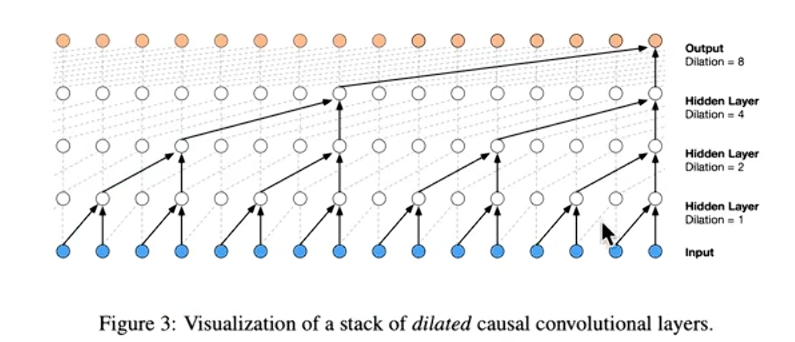

所以这个wavenet就是我们接下来要实现的结构。我们下面开始具体操作。首先要把我们的输入从3个字符变为8个字符

In [74]:
# build the dataset
block_size = 8

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])        #80%
Xdev, Ydev = build_dataset(words[n1:n2])    #10%
Xte, Yte = build_dataset(words[n2:])        #10%

torch.Size([182441, 8]) torch.Size([182441])
torch.Size([22902, 8]) torch.Size([22902])
torch.Size([22803, 8]) torch.Size([22803])


In [75]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[i.item()] for i in x), '-->', itos[y.item()])

........ --> e
.......e --> l
......el --> i
.....eli --> a
....elia --> n
...elian --> y
..eliany --> s
.elianys --> .
........ --> t
.......t --> r
......tr --> o
.....tro --> y
....troy --> .
........ --> m
.......m --> a
......ma --> r
.....mar --> k
....mark --> u
...marku --> s
..markus --> .


In [76]:
n_embd = 10     # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200  # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

model = Sequential([ 
    Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameters init, 参数初始化
with torch.no_grad():
    model.layers[-1].weight *= 0.1    # output layer is "weak" at the beginning, 输出层的权重初始化较小，让最后一层变得less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True

22097


这里题外话一嘴
karpathy顺便做了一下这个8个输入的情况在原本神经网络下的训练结果，可以看到train 1.918, val 2.027
相比于3个输入的 train 2.058, val 2.106的情况来说确实有提升，但这个提升也就是只是因为增大了数据规模
我们当然可以通过增加输入字母的方式来取得更好的结果，但这样还是在原有基础上，并没有使用wavenet

现在我们得到的是8个字符的输入，它们形如 1 2 3 4 5 6 7 8

我们知道，我们的embedding层把每个字符嵌入10维，所以对于一个批次(比如说4)，我们会先得到一个 (4,8,10)的tensor

在传统的方法里，我们会把后面的两个维度 8 和 10 拼接成 80 ，这也是前面的flatten layer干的，得到一个 (4,80)的tensor，然后再把这个tensor输入到线性层(linear layer)得到(4,200)的tensor

但是在wavenet这里，我们并不希望一开始就把它拼接成80，我们希望两两组合成bigram，形如 (1 2) (3 4) (5 6) (7 8) 这样，然后再经过flatten层，再进入线性层。

对于 (1 2) (3 4) (5 6) (7 8) 这样的结构，我们也希望平行的去处理，在一整个batch(4 个 example)里同时去处理

In [58]:
# 首先，pytorch的矩阵乘法 @ 非常强大，一般来说我们会进行这样的矩阵操作
(torch.randn(4,80) @ torch.randn(80,200)).shape
# 我们会得到一个 (4,200) 的矩阵，这个矩阵的每一行都是一个长度为200的向量，表示4个样本经过线性变换后的结果。

torch.Size([4, 200])

In [62]:
# 但实际上，@ 操作非常灵活，它可以只对最后一个维度进行相乘，所以我们就可以得到这样的结果
(torch.randn(4,5,80) @ torch.randn(80,200)).shape
# 我们会得到一个 (4,5,200) 的矩阵

torch.Size([4, 5, 200])

In [65]:
# 所以，为了实现上面提到的(1 2) (3 4) (5 6) (7 8) 这样的结构，我们希望一个batch里的(4,8,10)不是拼接成(4,80)，而是作为诸如(4,4,20)这样的结构来处理。这样就能实现bigram
(torch.randn(4,4,20) @ torch.randn(20,200)).shape
# 这样就是一个batch里4个样本，每个样本有4个bigram，每个bigram是一个长度为20的向量，经过线性变换后得到一个长度为200的向量。
# 所以我们需要对flatten层、linear层进行一些改动：让flatten层不再把(4,8,10)展平成(4,80)，而是展平成(4,4,20)，让linear层可以处理(4,4,20)这样的输入。

torch.Size([4, 4, 200])

下面我们开始对神经网络进行修改，以适合wavenet的结构

In [69]:
e = torch.randn(4,8,10)
e[:,::2,:]      # 这个会得到所有的双数，也就是原本tensor的第二维里的0,2,4,6索引的元素
e[:,1::2,:]     # 这个会得到所有的odd也就是单数，也就是原本tensor的第二维里的1,3,5,7索引的元素
explicit = torch.cat([e[:,::2,:], e[:,1::2,:]], dim=2)    # 这个会把双数和单数拼接起来，得到一个(4,4,20)的tensor，也就是我们所要的
explicit.shape

torch.Size([4, 4, 20])

In [72]:
(e.view(4,4,20) ==   explicit).all()    # 用view操作也能得到一样的结果

tensor(True)

In [73]:
class FlattenConsecutive:      # 所以这里我们对flatten层进行改动

    def __init__(self,n):
        self.n = n    # 这个n表示我们要把多少个连续的元素展平在一起，比如n=2表示把每两个连续的元素展平在一起

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)    # 这里我们把x展平成(B, T//n, C*n)的形状，也就是把每n个连续的元素展平在一起
        if x.shape[1]==1:    # 如果展平后只有一个元素，那么我们就把它展平成(B, C*n)的形状，也就是把第二维去掉
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    

In [93]:
n_embd = 10     # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 68  # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

model = Sequential([ 
    Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameters init, 参数初始化
with torch.no_grad():
    model.layers[-1].weight *= 0.1    # output layer is "weak" at the beginning, 输出层的权重初始化较小，让最后一层变得less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True

22397


In [94]:
ix = torch.randint(0, Xtr.shape[0], (4,))  # 看一下只有4个样本的batch的情况
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  8, 21, 19, 20, 15],
        [ 0,  0,  0,  0,  0,  0,  0,  3],
        [ 0,  0,  0,  0,  0,  0, 25, 21],
        [ 0,  0,  0,  0,  0,  0,  0,  5]])

In [96]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

# 这里查看一些每一层的输出tensor形状情况
# 这里第1个embedding层的输出是(4,8,10)，也就是4个样本，每个样本有8个字符，每个字符用一个10维的向量表示。 
# 第1个FlattenConsecutive(2)层的输出是(4,4,20)，也就是把每两个连续的字符展平在一起，得到4个bigram，每个bigram用一个20维的向量表示。
# 第1个Linear层的输出是(4,4,68)，也就是把每个bigram映射到一个68维的向量表示。
# 第1个BatchNorm1d层的输出是(4,4,68)，也就是对每个bigram的68维向量进行批归一化。
# 第1个Tanh层的输出是(4,4,68)，也就是对每个bigram的68维向量进行tanh激活。
# 下面以此类推不多赘述

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


到这里我们就得到了一个三层的神经网络，由8->4->2->1输出，这和Wavenet那篇论文里的网络架构已经十分接近了(那边用的是四层，16个输入，我们用的是8个)

In [97]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.9630
  10000/200000: 2.2381
  20000/200000: 1.9526
  30000/200000: 2.2056
  40000/200000: 2.1331
  50000/200000: 2.2529
  60000/200000: 1.5069
  70000/200000: 1.7260
  80000/200000: 2.2530
  90000/200000: 1.8664
 100000/200000: 2.0023
 110000/200000: 2.1494
 120000/200000: 2.5307
 130000/200000: 1.6575
 140000/200000: 1.6097
 150000/200000: 1.9716
 160000/200000: 1.9710
 170000/200000: 2.1914
 180000/200000: 1.9119
 190000/200000: 1.6050


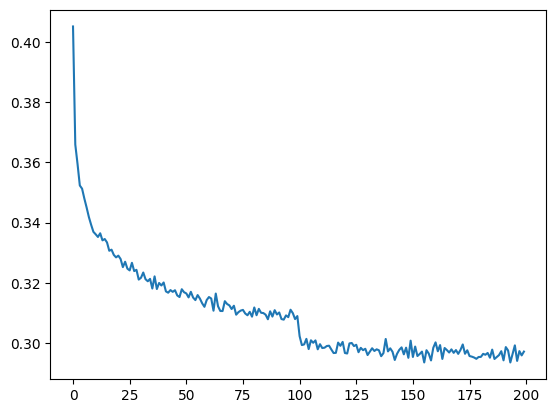

In [98]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
# 这里把lossi每1000个点取平均，画出平滑的曲线

In [99]:
# put layers into eval mode (needed for batchnorm especially)   进行评估模式，特别是对于batchnorm层
for layer in model.layers:
        layer.training = False

In [100]:
# evaluate the loss
@torch.no_grad()

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9486702680587769
val 2.0253942012786865


这里可以看到，我们改进过后的网络训练情况，train 1.94 val 2.02
和之前的对比一下(这里引用karpathy的数据)

- original(3 character content + 200 hidden neurons, 12k params): train 2.058, val 2.105
- content:3->8(22k params): train 1.918, val 2.027
- flat->hierarchical(22k params): train 1.941, val 2.029

对比可以发现，在参数相同的情况下(都是22k)，采用类wavenet的分层架构似乎并没有给我们带来提升。原有架构在引入8个上下文字符的情况下和我们打成平手

但这里仍然有两点需要指出。首先在我们的分层模型里，我们的模型的结构并没有细致的调整，只是简单堆叠了3层，里面还有许多超参数可以调试。其次那里batchnorm1d层实际上还有个小bug(PS:这里我真没绷住，karpathy就不能一口气修完吗？非要等到练完了再说)


In [101]:
# 这里我们先来看batch norm的bug
# 在BatchNorma1D里面，我们定义的batch mean部分具体操作如下
# 这在处理两个维度的tensor时没问题，但是在处理3个维度的tensor时就会有问题，只不过因为广播规则的存在，可能不会报错，但是结果就不对了
e = torch.randn(32,4,68)
emean = e.mean(0, keepdim=True)     # 这里得到的结果是 1 4 68 的tensor，这里的mean是对第0维求均值，也就是对32个样本求均值，得到一个(1,4,68)的tensor，仍然保留了第1维4
evar = e.var(0, keepdim=True)       # 这里得到的结果是 1 4 68 的tensor，操作和上面一样，也保留了第1维4
ehat = (e-emean)/torch.sqrt(evar+1e-5)    # 这里得到的结果是 32 4 68 的tensor，操作和上面一样，也保留了第1维4
ehat.shape

torch.Size([32, 4, 68])

In [102]:
# 同样的，我们来看batch norm里的running mean
model.layers[3].running_mean.shape    # 这里得到的结果也是1 4 68的tensor，而不是我们想要的1 1 68(也就是68)tensor

torch.Size([1, 4, 68])

所以在这里，batchnorm实际工作在4 68个channels上而不是68个channels，我们事实上独立维护了这4个位置的数据，而不是把这个4也当作batch的维度进行正则化

目前的batchnorm只对32求了平均，而我们实际上希望对32 4求平均来正则化

这里再提一点，实际上，查阅pytorch文档，在torch.mean里面，具体的参数形如torch.mean(input, dim, keepdim=False,*,dtype=None,out=None)
这里的dim参数可以是int，指定某一维度，也可以是tuple of ints，指定几个维度

In [105]:
# 所以这里，我们不单单对第0维度求均值和方差，而是对第0维度和第1维度同时求均值和方差，这样就能得到我们想要的结果
e = torch.randn(32,4,68)
emean = e.mean((0,1), keepdim=True)
evar = e.var((0,1), keepdim=True)
ehat = (e-emean)/torch.sqrt(evar+1e-5) 
emean.shape
# 这里就能正常得到1 1 68的tensor了

torch.Size([1, 1, 68])

In [106]:
# 修复batchnorm的bug
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters(trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers(trained with a running 'momentum updata')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)         # 这里改成考虑到输入的tensor可能是2维或者3维，所以求平均的维度也要分开讨论
            xmean=x.mean(dim, keepdim=True)   # batch mean, 计算当前批次的均值
            xvar=x.var(dim, keepdim=True)     # batch variance, 计算当前批次的方差
        else:
            xmean=self.running_mean
            xvar=self.running_var

        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)    # normalize the batch, 对当前批次的数据进行标准化
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = self.momentum * xmean + (1-self.momentum) * self.running_mean
                self.running_var = self.momentum * xvar + (1-self.momentum) * self.running_var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

这里再额外提一嘴，我们构造的BatchNorm1d和pytorch官方的BatchNorm1d还是有不同
官方的接收的参数是(N,C)或者(N,C,L)，对于第二种情况，它求和的维度是第0维和第2维，我们自己接收的参数是(N,C)或者(N,L,C)，对于第二种情况，求和的维度是第0维和第1维

下面我就不再重新训练了，这里直接引用karpathy的结果

在修正BatchNorma1D的bug之后，我们的训练情况是 train 1.91, val 2.022

再和之前所有的结果对比一下

- original(3 character content + 200 hidden neurons, 12k params): train 2.058, val 2.105
- content:3->8(22k params): train 1.918, val 2.027
- flat->hierarchical(22k params): train 1.941, val 2.029
- fix bug in batchnorm: train 1.91, val 2.022

这次可以看到效果相比于之前的得到了提升

下面karpathy又试了增加网络的规模，n_embd = 24, n_hidden = 128
参数量达到了76k，训练的时间变得更长了，这里我也直接引用他的结果

训练的结果
- original(3 character content + 200 hidden neurons, 12k params): train 2.058, val 2.105
- content:3->8(22k params): train 1.918, val 2.027
- flat->hierarchical(22k params): train 1.941, val 2.029
- fix bug in batchnorm: train 1.91, val 2.022
- scale up the network: n_embd = 24, n_hidden = 128(76k params): train 1.769, val 1.993

可以看到效果更好了

这里karpathy总结了一下，尽管我们最后得到效果的提升，从2.1到1.9，但是他并不希望我们聚焦于这个，因为我们在训练的时候完全处于黑暗之中，没有experimental harness，完全在瞎猜超参数什么的。而且我们也没有完全使用那篇wavenet论文的架构。尽管我们使用类似的多层神经网络，但是在前向传播过程中，我们并没有采用论文的gate linear、残差网络等等。

然后他也稍微提了一下目前我们这里做的和后面的卷积神经网络的一些联系。事实上我们之所以用卷积(convolutions)，纯粹是为了效率考虑，它并没有改变我们目前使用的模型，下面是一个简单的例子。

In [118]:
# 这是随机的一个8个字母的样本
for x,y in zip(Xtr[7:15], Ytr[7:15]):
    print(''.join(itos[i.item()] for i in x), '-->', itos[y.item()])

.elianys --> .
........ --> t
.......t --> r
......tr --> o
.....tro --> y
....troy --> .
........ --> m
.......m --> a


In [119]:
# forward a single example
logits = model(Xtr[[7]])
logits.shape

torch.Size([1, 27])

In [120]:
# forward all of them
logits = torch.zeros(8,27)
for i in range(8):
    logits[i] = model(Xtr[[7+i]])
logits.shape

# convolution is a "for loop"
# allows us to forward Linear layers efficiently over space
# 简单说，卷积操作可以看作是一个“for循环”，它允许我们在空间上高效地前向传播线性层。也就是说，我们可以将一个线性层应用于输入的每个位置，而不需要显式地写出循环，从而提高计算效率。

torch.Size([8, 27])